In [1]:
# ── Cellule 1 : Imports ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
print(" Imports OK")

 Imports OK


In [2]:
# ── Cellule 2 : Chargement des fichiers ───────────────────────────────────────
PATH = "../data/raw/"

# Fichiers normaux
normal2023 = pd.read_csv(PATH + "envois_colis_2023.csv", sep=";", encoding='latin1')
normal2024 = pd.read_csv(PATH + "envois_colis_2024.csv", sep=";", encoding='latin1')
normal2025 = pd.read_csv(PATH + "envois_colis_2025.csv", sep=";", encoding='latin1')
normal2026 = pd.read_csv(PATH + "envois_colis_2026.csv", sep=";", encoding='latin1')

# Fichiers express
express2024 = pd.read_csv(PATH + "envois_express_2024.csv", sep=";", encoding='latin1')
express2025 = pd.read_csv(PATH + "envois_express_2025.csv", sep=";", encoding='latin1')
express2026 = pd.read_csv(PATH + "envois_express_2026.csv", sep=";", encoding='latin1')

print(" Fichiers chargés")
print(f"Normal   : {len(normal2023)+len(normal2024)+len(normal2025)+len(normal2026):,} lignes")
print(f"Express  : {len(express2024)+len(express2025)+len(express2026):,} lignes")
print(f"TOTAL    : {len(normal2023)+len(normal2024)+len(normal2025)+len(normal2026)+len(express2024)+len(express2025)+len(express2026):,} lignes")

C:\Users\eyato\AppData\Local\Temp\ipykernel_26084\3259449895.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  normal2023 = pd.read_csv(PATH + "envois_colis_2023.csv", sep=";", encoding='latin1')
C:\Users\eyato\AppData\Local\Temp\ipykernel_26084\3259449895.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  normal2024 = pd.read_csv(PATH + "envois_colis_2024.csv", sep=";", encoding='latin1')
C:\Users\eyato\AppData\Local\Temp\ipykernel_26084\3259449895.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  express2024 = pd.read_csv(PATH + "envois_express_2024.csv", sep=";", encoding='latin1')


 Fichiers chargés
Normal   : 386,263 lignes
Express  : 868,302 lignes
TOTAL    : 1,254,565 lignes


In [3]:
# ── Cellule 3 : Vue d'ensemble ────────────────────────────────────────────────
fichiers = {
    "normal2023": normal2023,
    "normal2024": normal2024,
    "normal2025": normal2025,
    "normal2026": normal2026,
    "express2024": express2024,
    "express2025": express2025,
    "express2026": express2026,
}

for nom, df in fichiers.items():
    print(f"{nom} — {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"Valeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0]}")

normal2023 — 50,653 lignes × 18 colonnes
Valeurs manquantes :
cp              1
cite           25
ville         777
cpDest       1514
citeDest     1340
villeDest    1463
dtype: int64
normal2024 — 129,005 lignes × 18 colonnes
Valeurs manquantes :
cite           18
ville        1024
cpDest       1811
citeDest     3026
villeDest    4227
dtype: int64
normal2025 — 144,330 lignes × 18 colonnes
Valeurs manquantes :
cite          167
ville         519
cpDest       1877
citeDest     4002
villeDest    5781
dtype: int64
normal2026 — 62,275 lignes × 18 colonnes
Valeurs manquantes :
cite          211
ville         514
cpDest       1028
citeDest     2062
villeDest    4100
dtype: int64
express2024 — 235,137 lignes × 16 colonnes
Valeurs manquantes :
cp              8
cite          754
ville        3028
cpDest       1429
citeDest     5329
villeDest    8168
dtype: int64
express2025 — 342,798 lignes × 16 colonnes
Valeurs manquantes :
CodeService       13
cp                 1
cite             452
ville   

In [4]:
# ── Cellule 4 : Vérifier les doublons ────────────────────────────────────────
print("=== DOUBLONS SUR NumEnvoi ===")
for nom, df in fichiers.items():
    col = "NumEnvoi" if "normal" in nom else "NUMENVOI"
    doublons = df[col].duplicated().sum()
    print(f"{nom} : {doublons:,} doublons")

=== DOUBLONS SUR NumEnvoi ===
normal2023 : 577 doublons
normal2024 : 2,086 doublons
normal2025 : 967 doublons
normal2026 : 761 doublons
express2024 : 1,652 doublons
express2025 : 1,305 doublons
express2026 : 358 doublons


In [5]:
# ── Cellule 5 : Distribution des dates ───────────────────────────────────────
print("=== PLAGE DE DATES ===")
for nom, df in fichiers.items():
    col_date = "Date"
    df[col_date] = pd.to_datetime(df[col_date], format="%d/%m/%Y", errors="coerce")
    print(f"{nom} : {df[col_date].min()} → {df[col_date].max()}")

=== PLAGE DE DATES ===
normal2023 : 2023-01-01 00:00:00 → 2023-12-31 00:00:00
normal2024 : 2024-01-02 00:00:00 → 2024-12-31 00:00:00
normal2025 : 2025-01-02 00:00:00 → 2025-12-31 00:00:00
normal2026 : 2026-01-02 00:00:00 → 2026-07-01 00:00:00
express2024 : 2024-01-02 00:00:00 → 2024-12-31 00:00:00
express2025 : 2025-01-02 00:00:00 → 2025-12-31 00:00:00
express2026 : 2026-01-02 00:00:00 → 2026-11-12 00:00:00


In [6]:
# ── Cellule 6 : Statistiques Poids et Montant ─────────────────────────────────
print("=== POIDS ===")
for nom, df in fichiers.items():
    print(f"{nom} : min={df['Poids'].min()} | max={df['Poids'].max()} | moyenne={df['Poids'].mean():.2f}")

print("\n=== MONTANT ===")
for nom, df in fichiers.items():
    print(f"{nom} : min={df['Montant'].min()} | max={df['Montant'].max()} | moyenne={df['Montant'].mean():.2f}")

=== POIDS ===
normal2023 : min=0.0 | max=30.76 | moyenne=6.08
normal2024 : min=0.0 | max=30.3 | moyenne=3.23
normal2025 : min=0.0 | max=30.78 | moyenne=3.31
normal2026 : min=0.0 | max=30.0 | moyenne=3.20
express2024 : min=0.0 | max=43.2 | moyenne=0.73
express2025 : min=0.0 | max=1530.0 | moyenne=0.69
express2026 : min=0.0 | max=34.834 | moyenne=0.61

=== MONTANT ===
normal2023 : min=0.0 | max=770.0 | moyenne=36.56
normal2024 : min=0.0 | max=806.0 | moyenne=20.60
normal2025 : min=0.0 | max=862.0 | moyenne=20.35
normal2026 : min=0.0 | max=862.0 | moyenne=21.75
express2024 : min=5.0 | max=1112.0 | moyenne=18.18
express2025 : min=1.0 | max=1435.0 | moyenne=15.43
express2026 : min=2.0 | max=1172.0 | moyenne=12.63


In [7]:
# ── Cellule 7 : Valeurs uniques colonnes clés ─────────────────────────────────

# CodeService (express uniquement)
print("=== CodeService (express) ===")
for nom, df in fichiers.items():
    if "express" in nom:
        print(f"{nom} : {df['CodeService'].unique()}")

# Pays destination
print("\n=== Top 10 pays destination (normal2024) ===")
print(normal2024["paysDest"].value_counts().head(10))

print("\n=== Top 10 pays destination (express2024) ===")
print(express2024["paysDest"].value_counts().head(10))

# RefPaiement (normal uniquement)
print("\n=== RefPaiement (normal) ===")
print(normal2024["RefPaiement"].value_counts())

=== CodeService (express) ===
express2024 : ['EMS-N' 'RPP-I' 'EMS-I']
express2025 : ['RPP-I' 'EMS-N' 'EMS-I' nan]
express2026 : ['EMS-N' 'RPP-I' 'EMS-I']

=== Top 10 pays destination (normal2024) ===
paysDest
TN    102261
FR      8720
CA      2930
US      2215
IT      2197
QA      1743
DE      1487
SA      1023
OM       824
MA       677
Name: count, dtype: int64

=== Top 10 pays destination (express2024) ===
paysDest
TN    190777
FR     17921
IT      5043
DE      4350
CA      2386
US      1951
QA       816
GB       815
BE       803
ES       776
Name: count, dtype: int64

=== RefPaiement (normal) ===
RefPaiement
P    78754
C    50251
Name: count, dtype: int64


In [8]:
# ── Cellule 8 : Portée nationale vs internationale ────────────────────────────
print("=== PORTÉE (normal2024) ===")
portee_normal = normal2024["codepays"].apply(
    lambda x: "National" if x == "TN" else "International"
)
print(portee_normal.value_counts())
print(f"% National : {portee_normal.value_counts(normalize=True)['National']*100:.1f}%")

print("\n=== PORTÉE (express2024) ===")
portee_express = express2024["codepays"].apply(
    lambda x: "National" if x == "TN" else "International"
)
print(portee_express.value_counts())
print(f"% National : {portee_express.value_counts(normalize=True)['National']*100:.1f}%")

=== PORTÉE (normal2024) ===
codepays
National         128966
International        39
Name: count, dtype: int64
% National : 100.0%

=== PORTÉE (express2024) ===
codepays
National         231768
International      3369
Name: count, dtype: int64
% National : 98.6%


In [9]:
# ── Cellule 9 : Valeurs suspectes ────────────────────────────────────────────

# Poids négatif ou nul
print("=== POIDS <= 0 ===")
for nom, df in fichiers.items():
    suspect = df[df["Poids"] <= 0].shape[0]
    print(f"{nom} : {suspect} lignes")

# Montant négatif ou nul
print("\n=== MONTANT <= 0 ===")
for nom, df in fichiers.items():
    suspect = df[df["Montant"] <= 0].shape[0]
    print(f"{nom} : {suspect} lignes")

# cp = "0000000" (anomalie vue dans express2025)
print("\n=== cp = '0000000' (express) ===")
for nom, df in fichiers.items():
    if "express" in nom:
        suspect = df[df["cp"] == "0000000"].shape[0]
        print(f"{nom} : {suspect} lignes")

=== POIDS <= 0 ===
normal2023 : 13 lignes
normal2024 : 104 lignes
normal2025 : 83 lignes
normal2026 : 27 lignes
express2024 : 1 lignes
express2025 : 3 lignes
express2026 : 2 lignes

=== MONTANT <= 0 ===
normal2023 : 4 lignes
normal2024 : 10 lignes
normal2025 : 4 lignes
normal2026 : 2 lignes
express2024 : 0 lignes
express2025 : 0 lignes
express2026 : 0 lignes

=== cp = '0000000' (express) ===
express2024 : 1088 lignes
express2025 : 1263 lignes
express2026 : 420 lignes


In [10]:
# ── Vérification doublons NumEnvoi ───────────────────────────────────────────

# D'abord renommer NUMENVOI → NumEnvoi dans les fichiers express
for df in [express2024, express2025, express2026]:
    if "NUMENVOI" in df.columns:
        df.rename(columns={"NUMENVOI": "NumEnvoi"}, inplace=True)

# Reconstruire le dictionnaire après renommage
fichiers = {
    "normal2023": normal2023, "normal2024": normal2024,
    "normal2025": normal2025, "normal2026": normal2026,
    "express2024": express2024, "express2025": express2025,
    "express2026": express2026,
}

# Vérifier les doublons
for nom, df in fichiers.items():
    doublons = df[df.duplicated(subset=["NumEnvoi"], keep=False)]
    nb = len(doublons)
    if nb > 0:
        print(f"\n{'='*50}")
        print(f"📁 {nom} — {nb} lignes concernées")
        print(doublons[["NumEnvoi", "IdBordereau", "Date", "Poids", "Montant"]].head(6))


📁 normal2023 — 995 lignes concernées
           NumEnvoi  IdBordereau       Date  Poids  Montant
426   CP323198154TN         7392 2023-12-26   3.02      4.6
525   CP320821547TN         4203 2023-07-26   3.84      4.6
1714  CP319691907TN           22 2023-04-10  10.68     98.0
1715  CP319691907TN           23 2023-04-10  10.68     98.0
1718  CP319691941TN           21 2023-04-05  10.65     98.0
1719  CP319691915TN           21 2023-04-05   8.12     86.0

📁 normal2024 — 3216 lignes concernées
           NumEnvoi  IdBordereau       Date  Poids  Montant
590   UP001169541TN          146 2024-09-10  0.601     5.50
591   UP001169541TN          147 2024-09-10  0.601     5.50
1782  UP001730139TN          502 2024-06-07  0.285     5.00
1783  UP001730139TN          503 2024-06-07  0.285     5.00
2054  RR436355766TN          579 2024-02-14  0.013     6.25
2055  RR436355766TN          580 2024-02-14  0.013     6.25

📁 normal2025 — 1627 lignes concernées
          NumEnvoi  IdBordereau       Date  

In [11]:
# ── Analyser les types de doublons ───────────────────────────────────────────

for nom, df in fichiers.items():
    doublons = df[df.duplicated(subset=["NumEnvoi"], keep=False)]
    if len(doublons) == 0:
        continue

    print(f"\n{'='*50}")
    print(f"{nom}")

    # Type 1 : même NumEnvoi + même date + même poids + même montant
    type1 = doublons[
        doublons.duplicated(
            subset=["NumEnvoi", "Date", "Poids", "Montant"],
            keep=False
        )
    ]

    # Type 2 : même NumEnvoi mais données différentes
    type2 = doublons[
        ~doublons.duplicated(
            subset=["NumEnvoi", "Date", "Poids", "Montant"],
            keep=False
        )
    ]

    print(f"  Type 1 (vrais doublons — à supprimer) : {len(type1)} lignes")
    print(f"  Type 2 (NumEnvoi réutilisé)           : {len(type2)} lignes")


normal2023
  Type 1 (vrais doublons — à supprimer) : 759 lignes
  Type 2 (NumEnvoi réutilisé)           : 236 lignes

normal2024
  Type 1 (vrais doublons — à supprimer) : 2730 lignes
  Type 2 (NumEnvoi réutilisé)           : 486 lignes

normal2025
  Type 1 (vrais doublons — à supprimer) : 1341 lignes
  Type 2 (NumEnvoi réutilisé)           : 286 lignes

normal2026
  Type 1 (vrais doublons — à supprimer) : 898 lignes
  Type 2 (NumEnvoi réutilisé)           : 110 lignes

express2024
  Type 1 (vrais doublons — à supprimer) : 2419 lignes
  Type 2 (NumEnvoi réutilisé)           : 493 lignes

express2025
  Type 1 (vrais doublons — à supprimer) : 1983 lignes
  Type 2 (NumEnvoi réutilisé)           : 361 lignes

express2026
  Type 1 (vrais doublons — à supprimer) : 559 lignes
  Type 2 (NumEnvoi réutilisé)           : 121 lignes


In [12]:
normal2023.head()

,IdBordereau,IdBureau,Annee,Date,Heure,RefPaiement,NumEnvoi,IdPays,Poids,Montant,cp,cite,codepays,ville,cpDest,citeDest,paysDest,villeDest
0,183,2260,2023,2023-05-25,1520,C,CP321202823TN,TN,2.321,4.3,2260,rue souk,TN,degache,1000,tunis,TN,tunis
1,9030,3023,2023,2023-09-04,1031,C,CP323042007TN,FR,8.840,86.0,3023,sfax,TN,sfax,49100,anger,FR,france
2,43,2001,2023,2023-01-19,0819,P,UP000209902TN,IT,0.818,22.0,2001,ENNASR,TN,ARIANA,NaN,NaN,IT,NaN
3,35,2001,2023,2023-01-17,0824,C,CP319928206TN,FR,2.100,50.0,2001,ENNASR,TN,ARIANA,NaN,NaN,FR,NaN
4,126,2001,2023,2023-03-02,0841,C,CP319928798TN,IT,2.500,43.0,2001,ENNASR,TN,ARIANA,NaN,NaN,IT,NaN


In [13]:
# ── Vérification qualité par fichier ─────────────────────────────────────────

def verifier_qualite(df, nom, type_fichier="normal"):
    print(f"\n{'='*55}")
    print(f" {nom} — {len(df):,} lignes")
    print(f"{'='*55}")

    # Colonnes obligatoires selon le type
    if type_fichier == "normal":
        cols_obligatoires = ["NumEnvoi", "IdBureau", "Date", "Poids", "Montant", "paysDest", "codepays"]
    else:
        cols_obligatoires = ["NumEnvoi", "IdBureau", "Date", "Poids", "Montant", "paysDest", "CodeISOPays", "CodeService"]

    cols_descriptives = ["cp", "cite", "ville", "cpDest", "citeDest", "villeDest"]

    # Vérifier colonnes obligatoires
    print("\n Colonnes OBLIGATOIRES manquantes (→ suppression) :")
    for col in cols_obligatoires:
        if col not in df.columns:
            print(f"   {col} : colonne absente !")
            continue
        nb = df[col].isnull().sum()
        if nb > 0:
            print(f"   {col} : {nb:,} valeurs manquantes")
        else:
            print(f"   {col} :  OK")

    # Vérifier colonnes descriptives
    print("\n Colonnes DESCRIPTIVES manquantes (→ remplir 'Inconnu') :")
    for col in cols_descriptives:
        if col not in df.columns:
            continue
        nb = df[col].isnull().sum()
        if nb > 0:
            print(f"   {col} : {nb:,} valeurs manquantes")
        else:
            print(f"   {col} :  OK")

    # Vérifier cp invalide (0000000)
    if "cp" in df.columns:
        cp_invalide = df[df["cp"].astype(str).str.strip() == "0000000"].shape[0]
        if cp_invalide > 0:
            print(f"\n  cp = '0000000' : {cp_invalide:,} lignes (invalide → 'Inconnu')")

    # Vérifier poids et montant
    print("\n Valeurs numériques invalides (→ suppression) :")
    print(f"   Poids <= 0  : {(df['Poids'] <= 0).sum():,} lignes")
    print(f"   Montant <= 0: {(df['Montant'] <= 0).sum():,} lignes")
    if "Poids" in df.columns:
        print(f"   Poids > 30  : {(df['Poids'] > 30).sum():,} lignes")

    # Vérifier dates invalides
    if "Date" in df.columns:
        dates_nulles = df["Date"].isnull().sum()
        print(f"\n Dates invalides : {dates_nulles:,} lignes")


# Lancer la vérification sur tous les fichiers
for nom, df in fichiers.items():
    type_f = "express" if "express" in nom else "normal"
    verifier_qualite(df, nom, type_f)


 normal2023 — 50,653 lignes

 Colonnes OBLIGATOIRES manquantes (→ suppression) :
   NumEnvoi :  OK
   IdBureau :  OK
   Date : 2 valeurs manquantes
   Poids :  OK
   Montant :  OK
   paysDest :  OK
   codepays :  OK

 Colonnes DESCRIPTIVES manquantes (→ remplir 'Inconnu') :
   cp : 1 valeurs manquantes
   cite : 25 valeurs manquantes
   ville : 777 valeurs manquantes
   cpDest : 1,514 valeurs manquantes
   citeDest : 1,340 valeurs manquantes
   villeDest : 1,463 valeurs manquantes

 Valeurs numériques invalides (→ suppression) :
   Poids <= 0  : 13 lignes
   Montant <= 0: 4 lignes
   Poids > 30  : 4 lignes

 Dates invalides : 2 lignes

 normal2024 — 129,005 lignes

 Colonnes OBLIGATOIRES manquantes (→ suppression) :
   NumEnvoi :  OK
   IdBureau :  OK
   Date : 11 valeurs manquantes
   Poids :  OK
   Montant :  OK
   paysDest :  OK
   codepays :  OK

 Colonnes DESCRIPTIVES manquantes (→ remplir 'Inconnu') :
   cp :  OK
   cite : 18 valeurs manquantes
   ville : 1,024 valeurs manquante

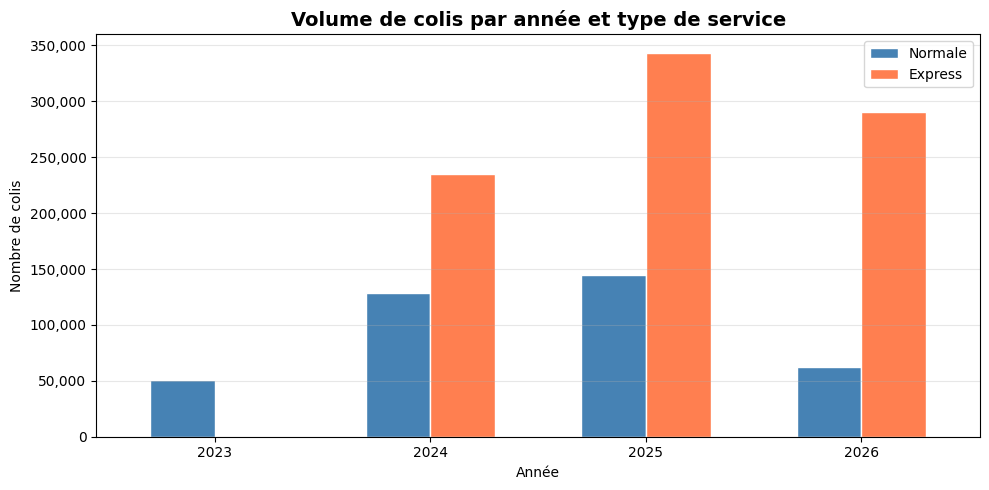

Sauvegardé : graphique_volume_par_annee.png


In [14]:
# ── Graphique 1 : Volume total par année et type ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Construire le dataframe de volume par année
data_vol = {
    2023: {'Normale': len(normal2023), 'Express': 0},
    2024: {'Normale': len(normal2024), 'Express': len(express2024)},
    2025: {'Normale': len(normal2025), 'Express': len(express2025)},
    2026: {'Normale': len(normal2026), 'Express': len(express2026)},
}
df_vol = pd.DataFrame(data_vol).T

fig, ax = plt.subplots(figsize=(10, 5))
df_vol.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white', width=0.6)
ax.set_title('Volume de colis par année et type de service', fontsize=14, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Nombre de colis')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=0)
ax.legend(['Normale', 'Express'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphique_volume_par_annee.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : graphique_volume_par_annee.png')

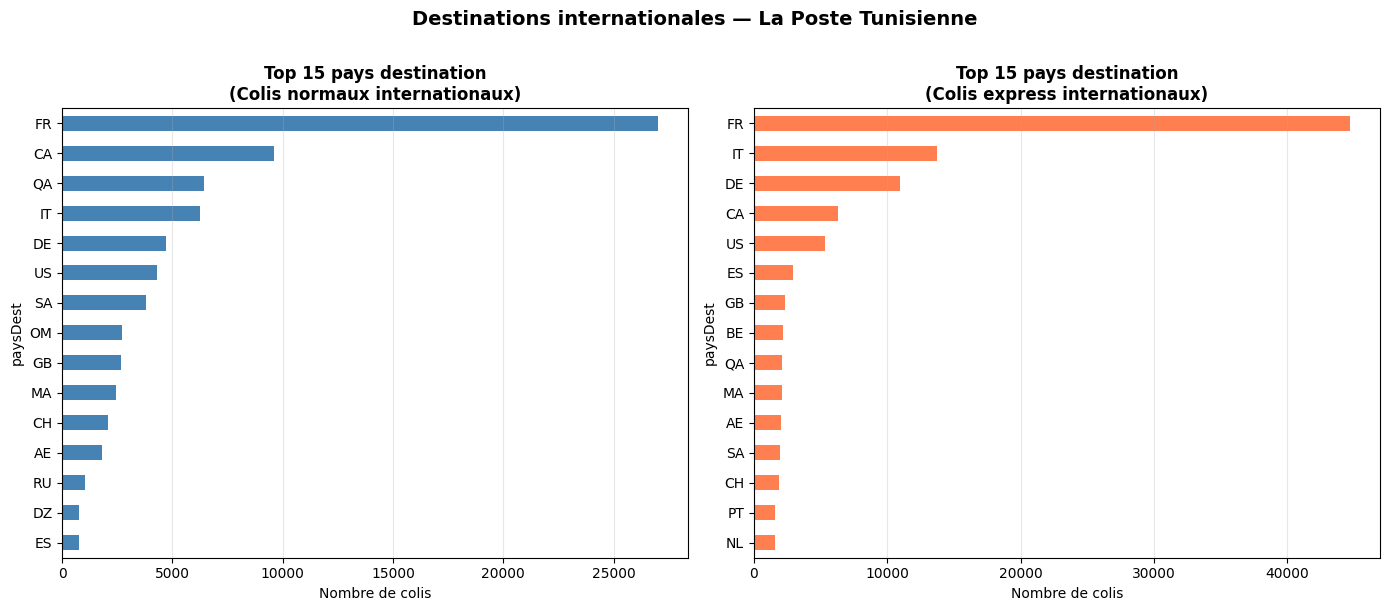

Sauvegardé : graphique_top15_pays.png


In [15]:
# ── Graphique 2 : Top 15 pays de destination (fichiers normaux) ───────────────
df_normale_all = pd.concat([normal2023, normal2024, normal2025, normal2026], ignore_index=True)
df_express_all = pd.concat([express2024, express2025, express2026], ignore_index=True)

# Portee correcte depuis IdPays (pas codepays)
df_normale_all['portee'] = df_normale_all['IdPays'].apply(
    lambda x: 'National' if str(x).strip().upper() == 'TN' else 'International'
)
intl_normale = df_normale_all[df_normale_all['portee'] == 'International']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normale international
top15_n = intl_normale['paysDest'].str.upper().str.strip().value_counts().head(15)
top15_n.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 pays destination\n(Colis normaux internationaux)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de colis')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Express international
intl_express = df_express_all[df_express_all['CodeISOPays'].str.upper() != 'TN']
top15_e = intl_express['paysDest'].str.upper().str.strip().value_counts().head(15)
top15_e.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 pays destination\n(Colis express internationaux)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de colis')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Destinations internationales — La Poste Tunisienne', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graphique_top15_pays.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : graphique_top15_pays.png')

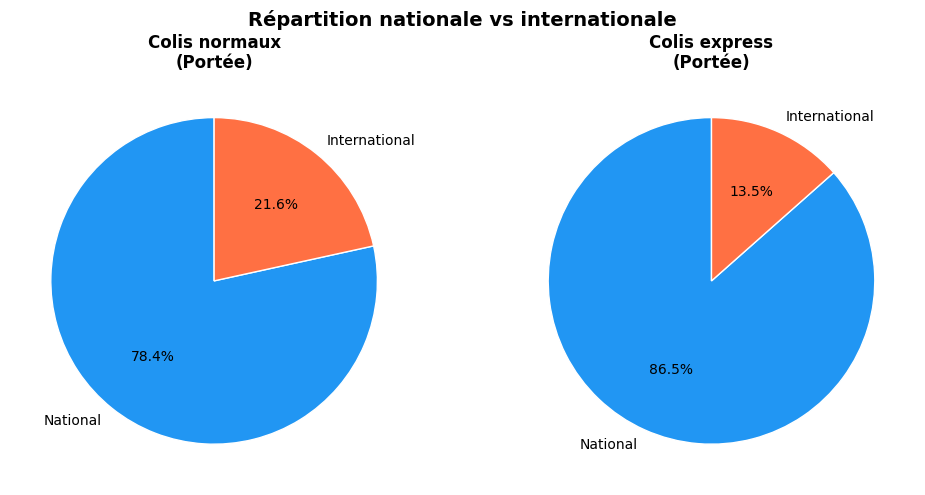

Sauvegardé : graphique_portee.png


In [16]:
# ── Graphique 3 : Répartition portée nationale vs internationale ──────────────
portee_n = df_normale_all['IdPays'].apply(
    lambda x: 'National' if str(x).strip().upper() == 'TN' else 'International'
).value_counts()

portee_e = df_express_all['CodeISOPays'].apply(
    lambda x: 'National' if str(x).strip().upper() == 'TN' else 'International'
).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ['#2196F3', '#FF7043']

axes[0].pie(portee_n, labels=portee_n.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Colis normaux\n(Portée)', fontsize=12, fontweight='bold')

axes[1].pie(portee_e, labels=portee_e.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Colis express\n(Portée)', fontsize=12, fontweight='bold')

plt.suptitle('Répartition nationale vs internationale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique_portee.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : graphique_portee.png')

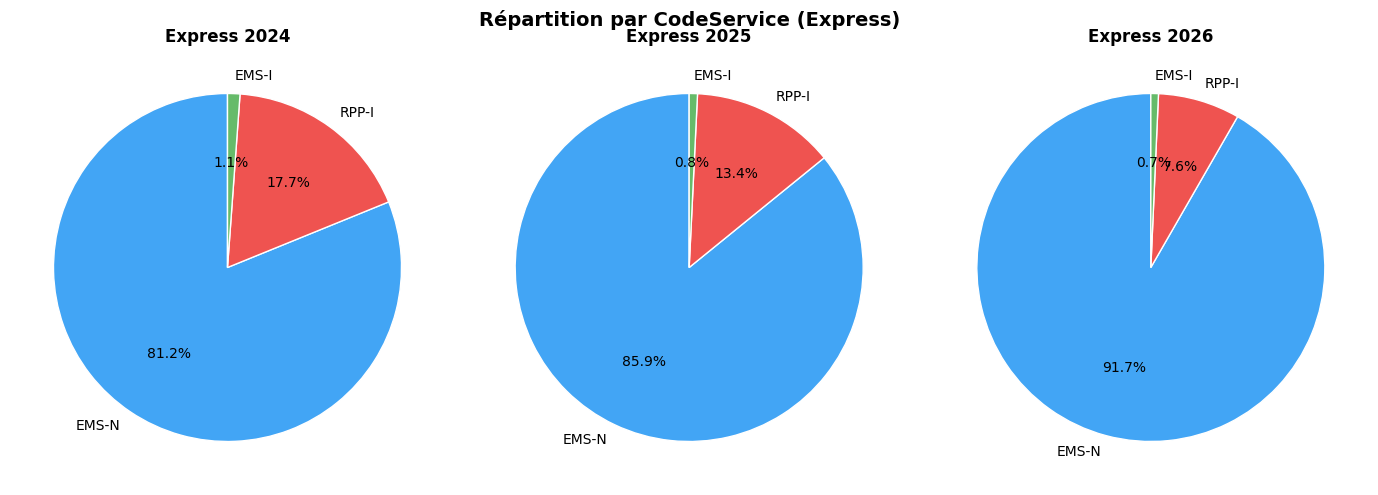

Sauvegardé : graphique_codeservice.png


In [17]:
# ── Graphique 4 : Distribution des CodeService express ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
annees_express = [
    ('express2024', express2024),
    ('express2025', express2025),
    ('express2026', express2026),
]

for i, (nom, df) in enumerate(annees_express):
    counts = df['CodeService'].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=['#42A5F5', '#EF5350', '#66BB6A'],
                startangle=90, wedgeprops={'edgecolor': 'white'})
    annee = nom.replace('express', '')
    axes[i].set_title(f'Express {annee}', fontsize=12, fontweight='bold')

plt.suptitle('Répartition par CodeService (Express)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique_codeservice.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : graphique_codeservice.png')

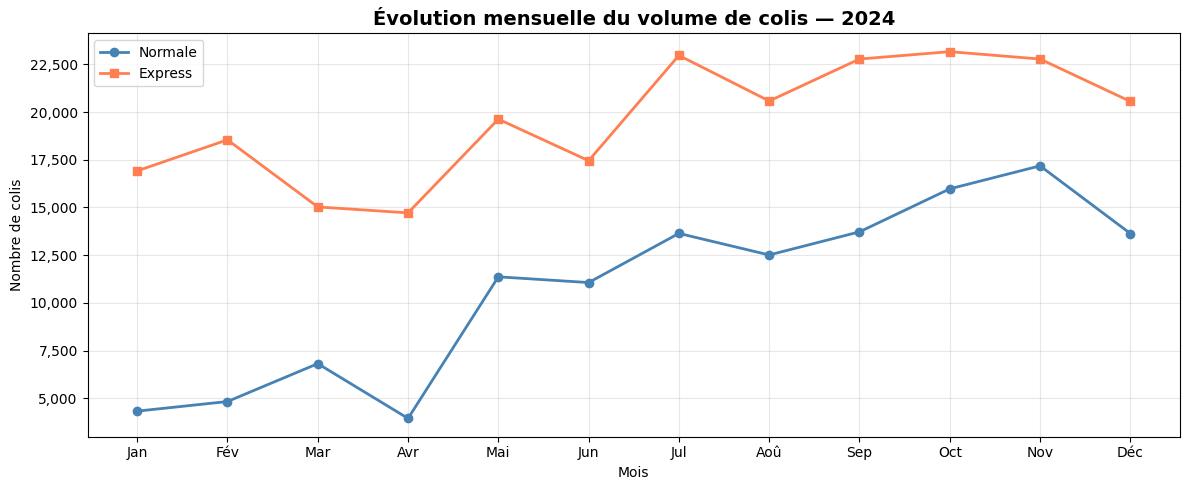

Sauvegardé : graphique_evolution_mensuelle.png


In [18]:
# ── Graphique 5 : Évolution mensuelle du volume (2024 complet) ────────────────
normal2024['mois'] = pd.to_datetime(normal2024['Date']).dt.month
express2024['mois'] = pd.to_datetime(express2024['Date']).dt.month

vol_mois_n = normal2024.groupby('mois').size()
vol_mois_e = express2024.groupby('mois').size()

mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
               'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vol_mois_n.index, vol_mois_n.values,
        marker='o', color='steelblue', linewidth=2, label='Normale')
ax.plot(vol_mois_e.index, vol_mois_e.values,
        marker='s', color='coral', linewidth=2, label='Express')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels)
ax.set_title('Évolution mensuelle du volume de colis — 2024',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Nombre de colis')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('graphique_evolution_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : graphique_evolution_mensuelle.png')

In [19]:
df_bureau[['id_bureau_src','cite','ville','code_postal']].drop_duplicates()

NameError: name 'df_bureau' is not defined

In [20]:
%whos DataFrame

Variable         Type         Data/Info
---------------------------------------
df               DataFrame    Shape: (290367, 16)
df_express_all   DataFrame    Shape: (868302, 16)
df_normale_all   DataFrame    Shape: (386263, 19)
df_vol           DataFrame    Shape: (4, 2)
doublons         DataFrame    Shape: (680, 16)
express2024      DataFrame    Shape: (235137, 17)
express2025      DataFrame    Shape: (342798, 16)
express2026      DataFrame    Shape: (290367, 16)
intl_express     DataFrame    Shape: (116914, 16)
intl_normale     DataFrame    Shape: (83289, 19)
normal2023       DataFrame    Shape: (50653, 18)
normal2024       DataFrame    Shape: (129005, 19)
normal2025       DataFrame    Shape: (144330, 18)
normal2026       DataFrame    Shape: (62275, 18)
type1            DataFrame    Shape: (559, 16)
type2            DataFrame    Shape: (121, 16)


In [22]:
df_express_all.columns

Index(['IdBordereau', 'IdBureau', 'Date', 'CodeService', 'NumEnvoi',
       'CodeISOPays', 'Poids', 'Montant', 'cp', 'cite', 'codepays', 'ville',
       'cpDest', 'citeDest', 'paysDest', 'villeDest'],
      dtype='object')

In [23]:
df_bureau_source = df_normale_all[
    [
        "IdBureau",
        "cp",
        "cite",
        "ville"
    ]
].drop_duplicates()

df_bureau_source.head()

,IdBureau,cp,cite,ville
0,2260,2260,rue souk,degache
1,3023,3023,sfax,sfax
2,2001,2001,ENNASR,ARIANA
35,1250,2011,2011,2011
73,2214,2214,hamma,tozeur


In [24]:
df_bureau_source.shape

(36224, 4)

In [25]:
df_bureau_express = df_express_all[
    [
        "IdBureau",
        "cp",
        "cite",
        "ville"
    ]
].drop_duplicates()

In [26]:
df_bureau = pd.concat(
    [
        df_bureau_source,
        df_bureau_express
    ]
).drop_duplicates()

In [27]:
df_bureau.shape

(107853, 4)

In [28]:
df_bureau[['cite','ville']].drop_duplicates().head(100)

,cite,ville
0,rue souk,degache
1,sfax,sfax
2,ENNASR,ARIANA
35,2011,2011
73,hamma,tozeur
...,...,...
1733,CITE GABES,GABES
1741,sombat,el hamma
1749,MIDOUN,MEDENINE
1758,tataoune,tataouine
